# Monte Carlo Stress Testing

Reviewing the portfolio loss simulation. Each scenario runs 10,000 draws to estimate expected loss, VaR and CVaR. The assumptions are deliberately simple. The point is to show the workflow, not build a production capital model.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
summary = pd.read_csv(ROOT / "data" / "processed" / "stress_test_summary.csv")
distribution = pd.read_csv(ROOT / "data" / "processed" / "monte_carlo_loss_distribution.csv")
summary[["scenario", "expected_loss", "value_at_risk_95", "conditional_value_at_risk_95", "expected_loss_rate"]]


,scenario,expected_loss,value_at_risk_95,conditional_value_at_risk_95,expected_loss_rate
0,baseline,6.668905e+06,7.185520e+06,7325264.16,0.052291
1,mild_stress,8.153222e+06,8.747561e+06,8890581.60,0.063930
2,severe_stress,1.014751e+07,1.080788e+07,10991791.80,0.079567


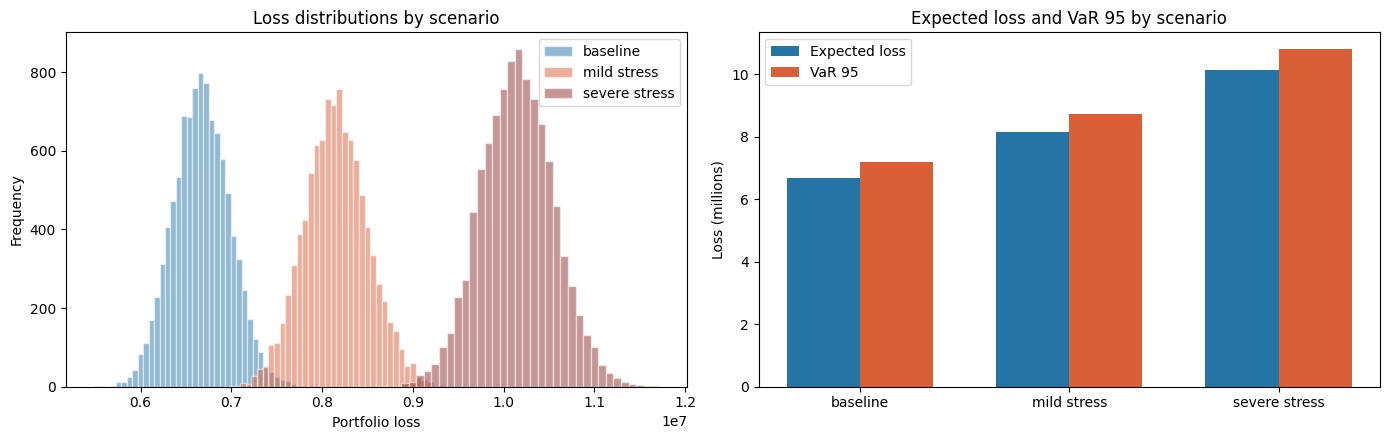

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for scenario, color in [("baseline", "#2474a6"), ("mild_stress", "#d95f36"), ("severe_stress", "#8b2e2e")]:
    losses = distribution[distribution["scenario"] == scenario]["loss"]
    axes[0].hist(losses, bins=40, alpha=0.5, color=color, edgecolor="white", label=scenario.replace("_", " "))

axes[0].set_title("Loss distributions by scenario")
axes[0].set_xlabel("Portfolio loss")
axes[0].set_ylabel("Frequency")
axes[0].legend()

scenarios = summary["scenario"].str.replace("_", " ")
x = range(len(scenarios))
width = 0.35
axes[1].bar([i - width/2 for i in x], summary["expected_loss"] / 1e6, width, label="Expected loss", color="#2474a6")
axes[1].bar([i + width/2 for i in x], summary["value_at_risk_95"] / 1e6, width, label="VaR 95", color="#d95f36")
axes[1].set_xticks(x)
axes[1].set_xticklabels(scenarios)
axes[1].set_ylabel("Loss (millions)")
axes[1].set_title("Expected loss and VaR 95 by scenario")
axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
distribution.groupby("scenario").agg(
    simulations=("loss", "size"),
    mean_loss=("loss", "mean"),
    median_loss=("loss", "median"),
    p95_loss=("loss", lambda values: values.quantile(0.95)),
    p99_loss=("loss", lambda values: values.quantile(0.99)),
)


,simulations,mean_loss,median_loss,p95_loss,p99_loss
scenario,,,,,
baseline,10000,6.668905e+06,6664983.75,7.185520e+06,7.416164e+06
mild_stress,10000,8.153222e+06,8146912.50,8.747561e+06,8.986730e+06
severe_stress,10000,1.014751e+07,10145025.00,1.080788e+07,1.110014e+07


The severe scenario pushes expected loss up by about 50 percent relative to baseline, and the VaR gap widens further in the tail. The distributions overlap substantially, which is realistic. A mild stress should not produce a completely different loss shape.
